# Section 11: Functional Annotation

This notebook documents whether the fine-mapped variants in the target gene show any signals in enhancer/promoter functional element regions.

The steps are:

1. Load the GWAS and QTL fine-mapping flattened table.
2. Load the annotation reference from [Nott et al., 2019, Science](10.1126/science.aay0793).
3. Visualize the signals using ggplot.

To apply this to other genes, simply use `Ctrl+F` to replace `BIN1` with the gene of interest, or change the gene name in the block below.

In [1]:
source('../../codes/utilis.R')

gene_name = 'BIN1'
target_gene_info <- get_gene_info(gene_name = gene_name)
gene_id <- target_gene_info$gene_info$region_id

── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.2     ✔ tibble    3.3.0
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.1.0     


── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors



Attaching package: ‘data.table’




The following objects are masked from ‘package:lubridate’:

    hour, isoweek, mday, minute, month, quarter, second, wday, week,
    yday, year




The following objects are masked from ‘package:dplyr’:

    between, first, last




The following object is masked from ‘package:purrr’:

    transpose





Attaching package: ‘cowplot’




The following object is masked from ‘package:lubridate’:

    stamp




In [2]:
target_gene_info$gene_info

region_id,#chr,start,end,TSS,LD_matrix_id,LD_sumstats_id,LD_sumstats_id_old,TADB_index,TADB_id,gene_start,gene_end,sliding_windows,gene_name
<chr>,<chr>,<dbl>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<chr>,<chr>
ENSG00000136717,chr2,123880000,130720000,127107287,"chr2:122654970-124537054,chr2:124537054-125689597,chr2:125689597-127728648,chr2:127728648-129107569,chr2:129107569-130787741","2_122654970-124537054,2_124537054-125689597,2_125689597-127728648,2_127728648-129107569,2_129107569-130787741","2_122654970-124537054,2_124537054_125689597,2_125689597_127728648,2_127728648_129107569,2_129107569_130787741","TADB_175,TADB_176,TADB_177","chr2_123011984_128107288,chr2_126048027_131718831,chr2_126535801_133037993",127107288,127048027,"chr2:116754139-124869570,chr2:118302225-128107288,chr2:120737102-131718831,chr2:123011984-133037993,chr2:126048027-134596399,chr2:126535801-135959342,chr2:130104846-136876443",BIN1


## Organize files

In [3]:
gwas_no_overlap <- suppressMessages(fread("/data/interactive_analysis/aw3600/case_example_codes/AD_GWAS_finemapping_109_blocks_top_loci_unified_any0.8ANDmin0.5_converged_no_duplicate.csv.gz"))

In [4]:
head(gwas_no_overlap)

study,variant_ID,region,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,z,cs_coverage_0.95_original,cs_coverage_0.7_original,cs_coverage_0.5_original,event_ID
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>
AD_Bellenguez_2022,chr10:11672508:C:T,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022
AD_Bellenguez_2022,chr10:11675398:T:C,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022
AD_Bellenguez_2022,chr10:11676332:T:C,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022
AD_Bellenguez_2022,chr10:11676714:A:G,chr10_10500888_12817813,1,1,1,0.9792165,6.97561,1,1,1,AD_Bellenguez_2022
AD_Bellenguez_2022,chr10:11677075:T:G,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022
AD_Bellenguez_2022,chr10:11678309:A:G,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022


In [5]:
library(data.table)
library(tidyverse)
gwas_no_overlap <- suppressMessages(fread("/data/interactive_analysis/aw3600/case_example_codes/AD_GWAS_finemapping_109_blocks_top_loci_unified_any0.8ANDmin0.5_converged_no_duplicate.csv.gz"))
gwas_no_overlap <- transform(gwas_no_overlap, variant_id_flip = gsub("(\\w+):(\\d+):([ATCG]+):([ATCG]+)", "\\1:\\2:\\4:\\3", variant_ID))

In [6]:
head(gwas_no_overlap)

study,variant_ID,region,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,z,cs_coverage_0.95_original,cs_coverage_0.7_original,cs_coverage_0.5_original,event_ID,variant_id_flip
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>,<chr>
AD_Bellenguez_2022,chr10:11672508:C:T,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11672508:T:C
AD_Bellenguez_2022,chr10:11675398:T:C,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11675398:C:T
AD_Bellenguez_2022,chr10:11676332:T:C,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11676332:C:T
AD_Bellenguez_2022,chr10:11676714:A:G,chr10_10500888_12817813,1,1,1,0.9792165,6.97561,1,1,1,AD_Bellenguez_2022,chr10:11676714:G:A
AD_Bellenguez_2022,chr10:11677075:T:G,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11677075:G:T
AD_Bellenguez_2022,chr10:11678309:A:G,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11678309:G:A


In [7]:
gwas_res_95 <- gwas_no_overlap %>% filter(cs_coverage_0.95 >0) %>% 
                    mutate(chr = str_split(variant_ID, ":", simplify = T) %>% .[,1], pos = str_split(variant_ID, ":", simplify = T) %>% .[,2])%>% 
                    mutate(cs_id_95 = ifelse(cs_coverage_0.95 > 0, paste(event_ID, region, cs_coverage_0.95, sep = '_'), NA),
                           cs_id_70 = ifelse(cs_coverage_0.7 > 0, paste(event_ID, region, cs_coverage_0.7, sep = '_'), NA),
                           cs_id_50 = ifelse(cs_coverage_0.5 > 0, paste(event_ID, region, cs_coverage_0.5, sep = '_'), NA))
gwas_res_70 <- gwas_no_overlap %>% filter((cs_coverage_0.95 > 0 | cs_coverage_0.7 > 0)) %>% 
    mutate(chr = str_split(variant_ID, ":", simplify = T) %>% .[,1], pos = str_split(variant_ID, ":", simplify = T) %>% .[,2])%>%
    mutate(cs_id_95 = ifelse(cs_coverage_0.95 > 0, paste(event_ID, region, cs_coverage_0.95, sep = '_'), NA),
            cs_id_70 = ifelse(cs_coverage_0.7 > 0, paste(event_ID, region, cs_coverage_0.7, sep = '_'), NA),
            cs_id_50 = ifelse(cs_coverage_0.5 > 0, paste(event_ID, region, cs_coverage_0.5, sep = '_'), NA))
gwas_res_50 <- gwas_no_overlap %>% filter((cs_coverage_0.95 > 0 | cs_coverage_0.7 > 0 | cs_coverage_0.5 > 0)) %>%
    mutate(chr = str_split(variant_ID, ":", simplify = T) %>% .[,1], pos = str_split(variant_ID, ":", simplify = T) %>% .[,2])%>% 
    mutate(cs_id_95 = ifelse(cs_coverage_0.95 > 0, paste(event_ID, region, cs_coverage_0.95, sep = '_'), NA),
            cs_id_70 = ifelse(cs_coverage_0.7 > 0, paste(event_ID, region, cs_coverage_0.7, sep = '_'), NA),
            cs_id_50 = ifelse(cs_coverage_0.5 > 0, paste(event_ID, region, cs_coverage_0.5, sep = '_'), NA))

In [8]:
# gwas_res_95 <- gwas_res %>% filter(cs_coverage_0.95_min_corr> 0, study == 'AD_Bellenguez_2022', method == 'RSS_QC_RAISS_imputed') %>%
#     # mutate(variant_id = paste0('chr', variant_id), context = study) %>% 
#     mutate(chr = str_split(variant_id, ":", simplify = T) %>% .[,1], pos = str_split(variant_id, ":", simplify = T) %>% .[,2])%>% 
#     mutate(cs_id_95 = ifelse(cs_coverage_0.95_min_corr> 0, paste(context, method, block, cs_coverage_0.95, sep = '_'), NA),
#             cs_id_70 = ifelse(cs_coverage_0.7_min_corr> 0, paste(context, method, block, cs_coverage_0.7, sep = '_'), NA),
#             cs_id_50 = ifelse(cs_coverage_0.5_min_corr> 0, paste(context, method, block, cs_coverage_0.5, sep = '_'), NA))
# gwas_res_70 <- gwas_res %>% filter((cs_coverage_0.95_min_corr> 0 | cs_coverage_0.7_min_corr> 0) & study == 'AD_Bellenguez_2022', method == 'RSS_QC_RAISS_imputed') %>% 
#     # mutate(variant_id = paste0('chr', variant_id), context = study) %>% 
#     mutate(chr = str_split(variant_id, ":", simplify = T) %>% .[,1], pos = str_split(variant_id, ":", simplify = T) %>% .[,2])%>% 
#     mutate(cs_id_95 = ifelse(cs_coverage_0.95_min_corr> 0, paste(context, method, block, cs_coverage_0.95, sep = '_'), NA),
#             cs_id_70 = ifelse(cs_coverage_0.7_min_corr> 0, paste(context, method, block, cs_coverage_0.7, sep = '_'), NA),
#             cs_id_50 = ifelse(cs_coverage_0.5_min_corr> 0, paste(context, method, block, cs_coverage_0.5, sep = '_'), NA))
# gwas_res_50 <- gwas_res %>% 
#     filter((cs_coverage_0.95_min_corr> 0 | cs_coverage_0.7_min_corr> 0 | cs_coverage_0.5_min_corr> 0) & study == 'AD_Bellenguez_2022', method == 'RSS_QC_RAISS_imputed') %>% 
#     # mutate(variant_id = paste0('chr', variant_id), context = study) %>% 
#     mutate(chr = str_split(variant_id, ":", simplify = T) %>% .[,1], pos = str_split(variant_id, ":", simplify = T) %>% .[,2])%>% 
#     mutate(cs_id_95 = ifelse(cs_coverage_0.95_min_corr> 0, paste(context, method, block, cs_coverage_0.95, sep = '_'), NA),
#             cs_id_70 = ifelse(cs_coverage_0.7_min_corr> 0, paste(context, method, block, cs_coverage_0.7, sep = '_'), NA),
#             cs_id_50 = ifelse(cs_coverage_0.5_min_corr> 0, paste(context, method, block, cs_coverage_0.5, sep = '_'), NA))

In [9]:
dim(gwas_res_95)
dim(gwas_res_70)
dim(gwas_res_50)

[1] 3256   18

[1] 6489   18

[1] 8505   18

## prepare data

### BIN1 data

In [10]:
library(tidyverse)

In [11]:
BIN1_result <- tryCatch({
  readRDS(paste0('Fungen_xQTL_allQTL.overlapped.gwas.export.',gene_name,'.rds'))
}, error = function(e) {
  message('Loading data from whole flatten table...')
  QTL_data <- fread("/data/interactive_analysis/aw3600/case_example_codes/all_top_loci_except_fsusie_snATAC_multigene.rds")
  BIN1_result <- QTL_data %>%  filter(gene_ID == gene_id, resource == "single_context")
  return(BIN1_result)
})
BIN1_result <- BIN1_result %>% filter(gene_ID == gene_id, resource == "single_context")

In [12]:
BIN1_result %>% head

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,conditional_effect,context,resource,lfsr,z
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,2,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA
2,127057057,127057058,T,G,chr2:127057058:G:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,0,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA
2,127074234,127074235,C,T,chr2:127074235:T:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127074768,127074769,T,C,chr2:127074769:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA
2,127074771,127074772,A,G,chr2:127074772:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,1,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA


In [13]:
BIN1_result <- BIN1_result %>% 
                    mutate(type = str_extract(context, "(eQTL|sQTL|pQTL)"),
                            cs_id_95 = ifelse(cs_coverage_0.95 > 0, paste(type, context, cs_coverage_0.95, sep = '_'), NA),
                            cs_id_70 = ifelse(cs_coverage_0.7 > 0, paste(type, context, cs_coverage_0.7, sep = '_'), NA),
                            cs_id_50 = ifelse(cs_coverage_0.5 > 0, paste(type, context, cs_coverage_0.5, sep = '_'), NA))

In [14]:
head(BIN1_result)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,⋯,PIP,conditional_effect,context,resource,lfsr,z,type,cs_id_95,cs_id_70,cs_id_50
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
2,127029679,127029680,G,A,chr2:127029680:A:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,⋯,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_2,eQTL_STARNET_eQTL_Mac_2,eQTL_STARNET_eQTL_Mac_2
2,127038393,127038394,A,G,chr2:127038394:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,⋯,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_2,eQTL_STARNET_eQTL_Mac_2,eQTL_STARNET_eQTL_Mac_2
2,127057057,127057058,T,G,chr2:127057058:G:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,2,2,⋯,0.29166606,-0.807067540339813,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_2,eQTL_STARNET_eQTL_Mac_2,NA
2,127074234,127074235,C,T,chr2:127074235:T:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,⋯,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_1,eQTL_STARNET_eQTL_Mac_1,eQTL_STARNET_eQTL_Mac_1
2,127074768,127074769,T,C,chr2:127074769:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,⋯,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_1,eQTL_STARNET_eQTL_Mac_1,eQTL_STARNET_eQTL_Mac_1
2,127074771,127074772,A,G,chr2:127074772:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,1,1,⋯,0.02916705,0.661035115045875,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_1,eQTL_STARNET_eQTL_Mac_1,eQTL_STARNET_eQTL_Mac_1


In [15]:
head(gwas_res_50)

study,variant_ID,region,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,z,cs_coverage_0.95_original,cs_coverage_0.7_original,cs_coverage_0.5_original,event_ID,variant_id_flip,chr,pos,cs_id_95,cs_id_70,cs_id_50
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AD_Bellenguez_2022,chr10:11672508:C:T,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11672508:T:C,chr10,11672508,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1
AD_Bellenguez_2022,chr10:11675398:T:C,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11675398:C:T,chr10,11675398,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1
AD_Bellenguez_2022,chr10:11676332:T:C,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11676332:C:T,chr10,11676332,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1
AD_Bellenguez_2022,chr10:11676714:A:G,chr10_10500888_12817813,1,1,1,0.9792165,6.97561,1,1,1,AD_Bellenguez_2022,chr10:11676714:G:A,chr10,11676714,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1
AD_Bellenguez_2022,chr10:11677075:T:G,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11677075:G:T,chr10,11677075,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1
AD_Bellenguez_2022,chr10:11678309:A:G,chr10_10500888_12817813,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr10:11678309:G:A,chr10,11678309,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1,AD_Bellenguez_2022_chr10_10500888_12817813_1


In [16]:
BIN1_result_olp <- BIN1_result %>% filter((cs_coverage_0.95 > 0 | cs_coverage_0.7 > 0 | cs_coverage_0.5 > 0) & variant_ID %in% gwas_res_50$variant_ID )
BIN1_result_olp%>%head

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,⋯,PIP,conditional_effect,context,resource,lfsr,z,type,cs_id_95,cs_id_70,cs_id_50
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
2,127112405,127112406,T,C,chr2:127112406:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,0.004656676,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA
2,127130408,127130409,A,C,chr2:127130409:C:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,3,⋯,0.226878009,-0.441707870992971,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3
2,127131541,127131542,T,C,chr2:127131542:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,3,⋯,0.226878009,-0.441707870992971,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3
2,127133850,127133851,C,A,chr2:127133851:A:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,0,4,⋯,0.168030061,0.16954460428147,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,NA,eQTL_STARNET_eQTL_Mac_4,NA
2,127135233,127135234,T,C,chr2:127135234:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,0,4,⋯,0.673711577,0.184125827675562,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,NA,eQTL_STARNET_eQTL_Mac_4,eQTL_STARNET_eQTL_Mac_4
2,127088379,127088380,TGGA,T,chr2:127088380:T:TGGA,ENSG00000136717,ROSMAP_AC_sQTL_chr2:127051243:127059010:clu_21774_-:PR:ENSG00000136717,0,1,⋯,0.089271035,0.29074137970699,ROSMAP_AC_sQTL_PR,single_context,NA,NA,sQTL,NA,sQTL_ROSMAP_AC_sQTL_PR_1,sQTL_ROSMAP_AC_sQTL_PR_1


In [17]:
gwas_res_BIN1 <-  gwas_res_50 %>% filter(cs_id_95 %in% (gwas_res_50 %>% filter(variant_ID %in% BIN1_result_olp$variant_ID) %>% pull(cs_id_95)%>% na.omit)|
                                         cs_id_70 %in% (gwas_res_50 %>% filter(variant_ID %in% BIN1_result_olp$variant_ID) %>% pull(cs_id_70)%>% na.omit)|
                                         cs_id_50 %in% (gwas_res_50 %>% filter(variant_ID %in% BIN1_result_olp$variant_ID) %>% pull(cs_id_50)%>% na.omit))
gwas_res_BIN1%>%head

study,variant_ID,region,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,z,cs_coverage_0.95_original,cs_coverage_0.7_original,cs_coverage_0.5_original,event_ID,variant_id_flip,chr,pos,cs_id_95,cs_id_70,cs_id_50
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AD_Bellenguez_2022,chr2:127133851:A:C,chr2_125689597_127728648,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_2022,chr2:127133851:C:A,chr2,127133851,AD_Bellenguez_2022_chr2_125689597_127728648_1,AD_Bellenguez_2022_chr2_125689597_127728648_1,AD_Bellenguez_2022_chr2_125689597_127728648_1
AD_Bellenguez_2022,chr2:127135234:C:T,chr2_125689597_127728648,1,1,1,1.0000000,20.07143,1,1,1,AD_Bellenguez_2022,chr2:127135234:T:C,chr2,127135234,AD_Bellenguez_2022_chr2_125689597_127728648_1,AD_Bellenguez_2022_chr2_125689597_127728648_1,AD_Bellenguez_2022_chr2_125689597_127728648_1
AD_Bellenguez_EADB_2022,chr2:127133851:A:C,chr2_125689597_127728648,1,1,1,NA,NA,NA,NA,NA,AD_Bellenguez_EADB_2022,chr2:127133851:C:A,chr2,127133851,AD_Bellenguez_EADB_2022_chr2_125689597_127728648_1,AD_Bellenguez_EADB_2022_chr2_125689597_127728648_1,AD_Bellenguez_EADB_2022_chr2_125689597_127728648_1
AD_Bellenguez_EADB_2022,chr2:127135234:C:T,chr2_125689597_127728648,1,1,1,0.9996894,13.21241,1,1,1,AD_Bellenguez_EADB_2022,chr2:127135234:T:C,chr2,127135234,AD_Bellenguez_EADB_2022_chr2_125689597_127728648_1,AD_Bellenguez_EADB_2022_chr2_125689597_127728648_1,AD_Bellenguez_EADB_2022_chr2_125689597_127728648_1
AD_Jansen_2021,chr2:127133851:A:C,chr2_125689597_127728648,1,1,1,1.0000000,14.00534,1,1,1,AD_Jansen_2021,chr2:127133851:C:A,chr2,127133851,AD_Jansen_2021_chr2_125689597_127728648_1,AD_Jansen_2021_chr2_125689597_127728648_1,AD_Jansen_2021_chr2_125689597_127728648_1
AD_Jansen_2021,chr2:127135234:C:T,chr2_125689597_127728648,1,1,1,NA,NA,NA,NA,NA,AD_Jansen_2021,chr2:127135234:T:C,chr2,127135234,AD_Jansen_2021_chr2_125689597_127728648_1,AD_Jansen_2021_chr2_125689597_127728648_1,AD_Jansen_2021_chr2_125689597_127728648_1


## PIP and Functional region plot

### Enhancer and promoter information

In [18]:
anno_df <- fread('/data/resource/Functional_annotation/FunGen_xQTL_annotation_Oct2024.txt', sep = '\t')

In [19]:
anno_df %>% head

chr,start,end,type,resource,TG
<chr>,<int>,<int>,<chr>,<chr>,<chr>
chr1,817069,817440,Astrocyte enhancers,NIHMS1066836,
chr1,818117,818345,Astrocyte enhancers,NIHMS1066836,
chr1,818682,818799,Astrocyte enhancers,NIHMS1066836,
chr1,904119,905001,Astrocyte enhancers,NIHMS1066836,
chr1,910178,910472,Astrocyte enhancers,NIHMS1066836,
chr1,939920,940068,Astrocyte enhancers,NIHMS1066836,


In [20]:
immune_noqtl <- fread('/data/interactive_analysis/rf2872/codes/xqtl-paper-conflict/AD_targets/APH1B/test/var_by_data_cat_Immune___Lymphatic___Cardiovascular_no_qtl.tsv', header = F)
Nervous_noqtl <- fread('/data/interactive_analysis/rf2872/codes/xqtl-paper-conflict/AD_targets/APH1B/test/var_by_data_cat_Nervous_no_qtl.tsv', header = F)

In [21]:
immune_noqtl <- immune_noqtl %>%
  separate_rows(V3, sep = ",")
Nervous_noqtl <- Nervous_noqtl  %>%
  separate_rows(V3, sep = ",")

In [22]:
anno_df <- rbind(anno_df, 
                 immune_noqtl %>% mutate(chr = str_split(V1, "_",simplify = T) %>% .[,1],
                       start = str_split(V1, "_",simplify = T) %>% .[,2] %>% as.numeric,
                       end = str_split(V1, "_",simplify = T) %>% .[,3] %>% as.numeric,
                       type = V3, resource = "NIAGADS_Immune", TG = '') %>% select(chr, start, end, type, resource, TG)
                ) %>% 
                rbind(., 
                 Nervous_noqtl %>% mutate(chr = str_split(V1, "_",simplify = T) %>% .[,1],
                       start = str_split(V1, "_",simplify = T) %>% .[,2] %>% as.numeric,
                       end = str_split(V1, "_",simplify = T) %>% .[,3] %>% as.numeric,
                       type = V3, resource = "NIAGADS_Nervous", TG = '') %>% select(chr, start, end, type, resource, TG)
                )

### BIN1

In [23]:
options(repr.plot.width=20, repr.plot.height=8)


In [24]:
head(BIN1_result_olp)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,⋯,PIP,conditional_effect,context,resource,lfsr,z,type,cs_id_95,cs_id_70,cs_id_50
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>
2,127112405,127112406,T,C,chr2:127112406:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,0.004656676,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA
2,127130408,127130409,A,C,chr2:127130409:C:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,3,⋯,0.226878009,-0.441707870992971,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3
2,127131541,127131542,T,C,chr2:127131542:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,3,⋯,0.226878009,-0.441707870992971,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3,eQTL_STARNET_eQTL_Mac_3
2,127133850,127133851,C,A,chr2:127133851:A:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,0,4,⋯,0.168030061,0.16954460428147,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,NA,eQTL_STARNET_eQTL_Mac_4,NA
2,127135233,127135234,T,C,chr2:127135234:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,0,4,⋯,0.673711577,0.184125827675562,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,NA,eQTL_STARNET_eQTL_Mac_4,eQTL_STARNET_eQTL_Mac_4
2,127088379,127088380,TGGA,T,chr2:127088380:T:TGGA,ENSG00000136717,ROSMAP_AC_sQTL_chr2:127051243:127059010:clu_21774_-:PR:ENSG00000136717,0,1,⋯,0.089271035,0.29074137970699,ROSMAP_AC_sQTL_PR,single_context,NA,NA,sQTL,NA,sQTL_ROSMAP_AC_sQTL_PR_1,sQTL_ROSMAP_AC_sQTL_PR_1


In [25]:
BIN1_com%>%colnames

ERROR: Error: object 'BIN1_com' not found


In [26]:
source('../../codes/utilis.R')
options(repr.plot.width=20, repr.plot.height=12)
BIN1_result_olp_cs <- BIN1_result %>% filter(cs_id_95 %in% (na.omit(BIN1_result_olp$cs_id_95)) | cs_id_70 %in% (na.omit(BIN1_result_olp$cs_id_70)))%>%
                    mutate(overlapped_with_gwas = ifelse(variant_ID %in% BIN1_result_olp$variant_ID | variant_ID %in% BIN1_result_olp$variant_id_flip, 'yes','no'))
BIN1_com <- rbind(gwas_res_BIN1 %>%mutate(overlapped_with_gwas = 'GWAS') %>%
                    mutate(`#chr` = str_split(variant_ID, ":", simplify = T) %>% .[,1], 
                           end = as.integer(str_split(variant_ID, ":", simplify = T) %>% .[,2]),
                           start = end-1,
                           a1 = str_split(variant_ID, ":", simplify = T) %>% .[,4],
                           a2 = str_split(variant_ID, ":", simplify = T) %>% .[,3],
                           context = study), 
                    BIN1_result_olp_cs, fill=TRUE) %>% 
               mutate(pos = str_split(variant_ID, ":", simplify = T)%>% .[,2]%>% as.numeric)
                                          

# # Ensure the correct factor level order for the legend
anno_df_TG <- anno_df %>% filter(TG == '' | TG == gene_name) %>% 
  mutate(type = factor(type, levels = c(
    unique(type[str_detect(type, "enhancers")]),
    unique(type[str_detect(type, "promoters")]),
          unique(type[str_detect(type, "MRPA")])

  )))
func_p <- create_genomic_context_plot(df = BIN1_com%>%rename(pip=PIP), annotation = anno_df_TG, 
                                      gene_body_start = target_gene_info$gene_info$gene_start, gene_body_end = target_gene_info$gene_info$gene_end, 
                                      expand_region = 10000, target_gene_info = target_gene_info, plot_title = gene_name)
ggsave(filename = 'plots/BIN1/sec11.functional_annotation.pdf', plot = func_p, height = 6, width = 14)


Warning message:
“There was 1 warning in `mutate()`.
ℹ In argument: `overlapped_with_gwas = ifelse(...)`.
Caused by warning:
! Unknown or uninitialised column: `variant_id_flip`.”


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


Warning message:
“Removed 16 rows containing missing values or values outside the scale range
(`geom_point()`).”


Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_segment()`).”


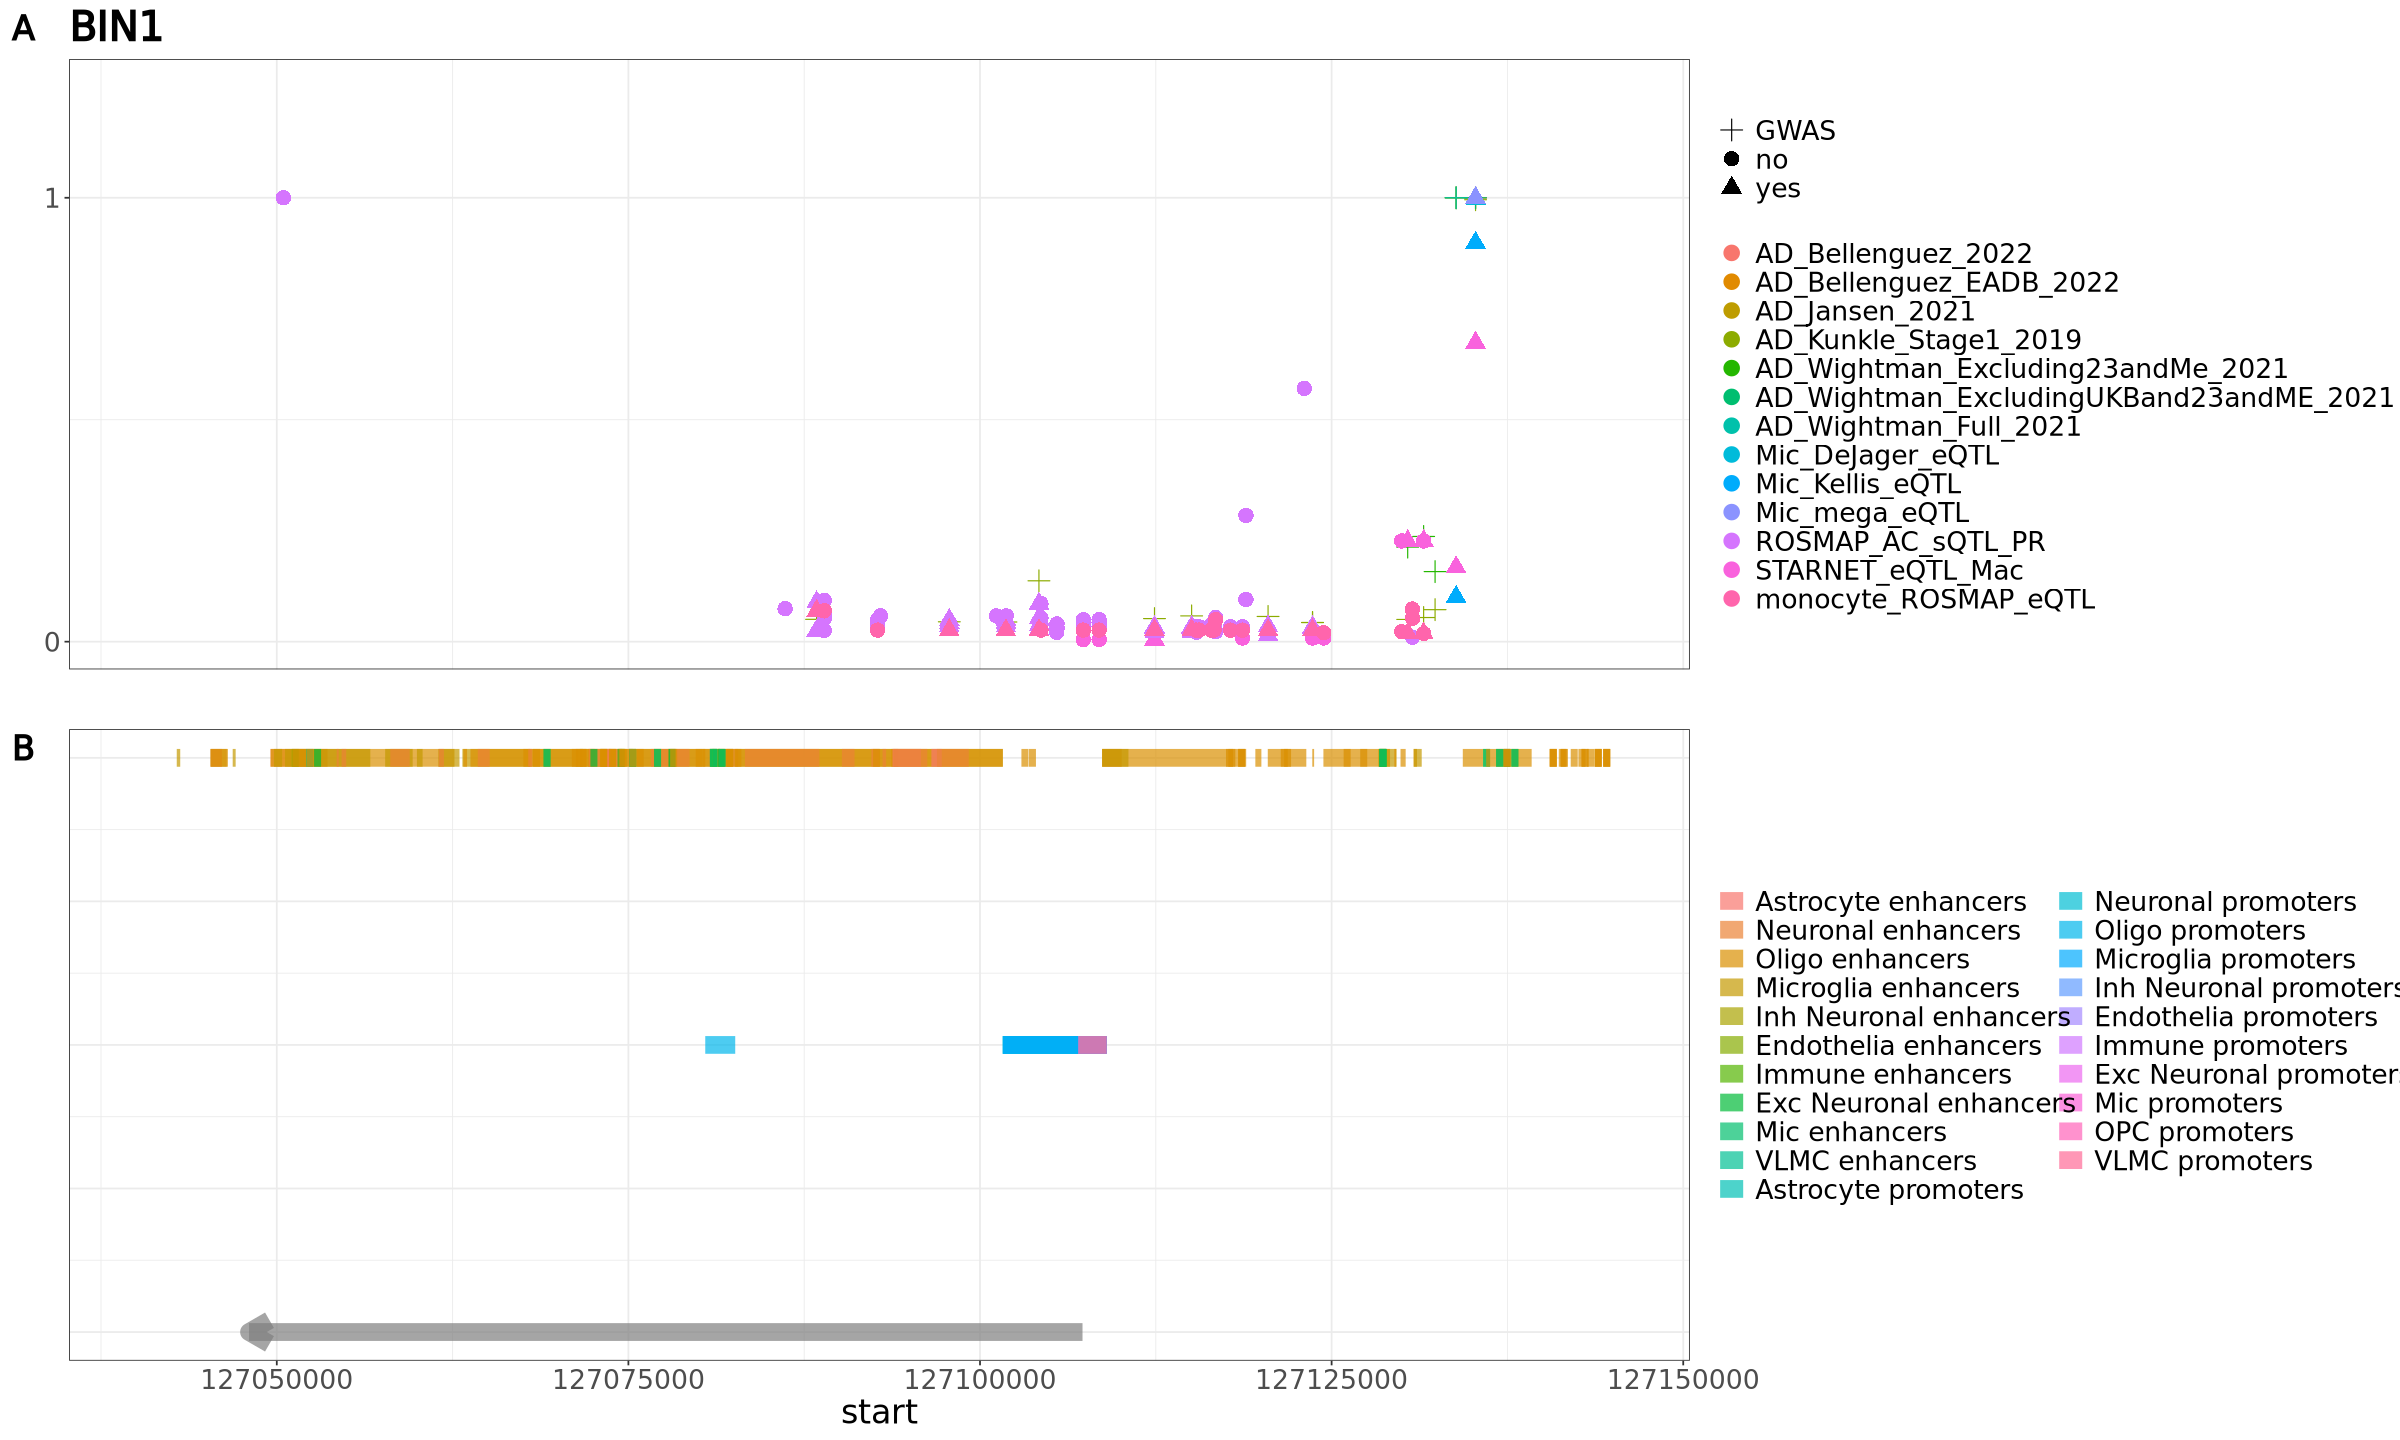

In [27]:
func_p

In [28]:
head(anno_df_TG)
anno_df_TG%>%filter(type == "Neuronal enhancers")

chr,start,end,type,resource,TG
<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>
chr1,817069,817440,Astrocyte enhancers,NIHMS1066836,
chr1,818117,818345,Astrocyte enhancers,NIHMS1066836,
chr1,818682,818799,Astrocyte enhancers,NIHMS1066836,
chr1,904119,905001,Astrocyte enhancers,NIHMS1066836,
chr1,910178,910472,Astrocyte enhancers,NIHMS1066836,
chr1,939920,940068,Astrocyte enhancers,NIHMS1066836,


chr,start,end,type,resource,TG
<chr>,<dbl>,<dbl>,<fct>,<chr>,<chr>
chr1,849634,850356,Neuronal enhancers,NIHMS1066836,
chr1,903830,905306,Neuronal enhancers,NIHMS1066836,
chr1,909917,910451,Neuronal enhancers,NIHMS1066836,
chr1,920916,920982,Neuronal enhancers,NIHMS1066836,
chr1,1021501,1021855,Neuronal enhancers,NIHMS1066836,
chr1,1022733,1022959,Neuronal enhancers,NIHMS1066836,
chr1,1024988,1025232,Neuronal enhancers,NIHMS1066836,
chr1,1026432,1026631,Neuronal enhancers,NIHMS1066836,
chr1,1026932,1028536,Neuronal enhancers,NIHMS1066836,


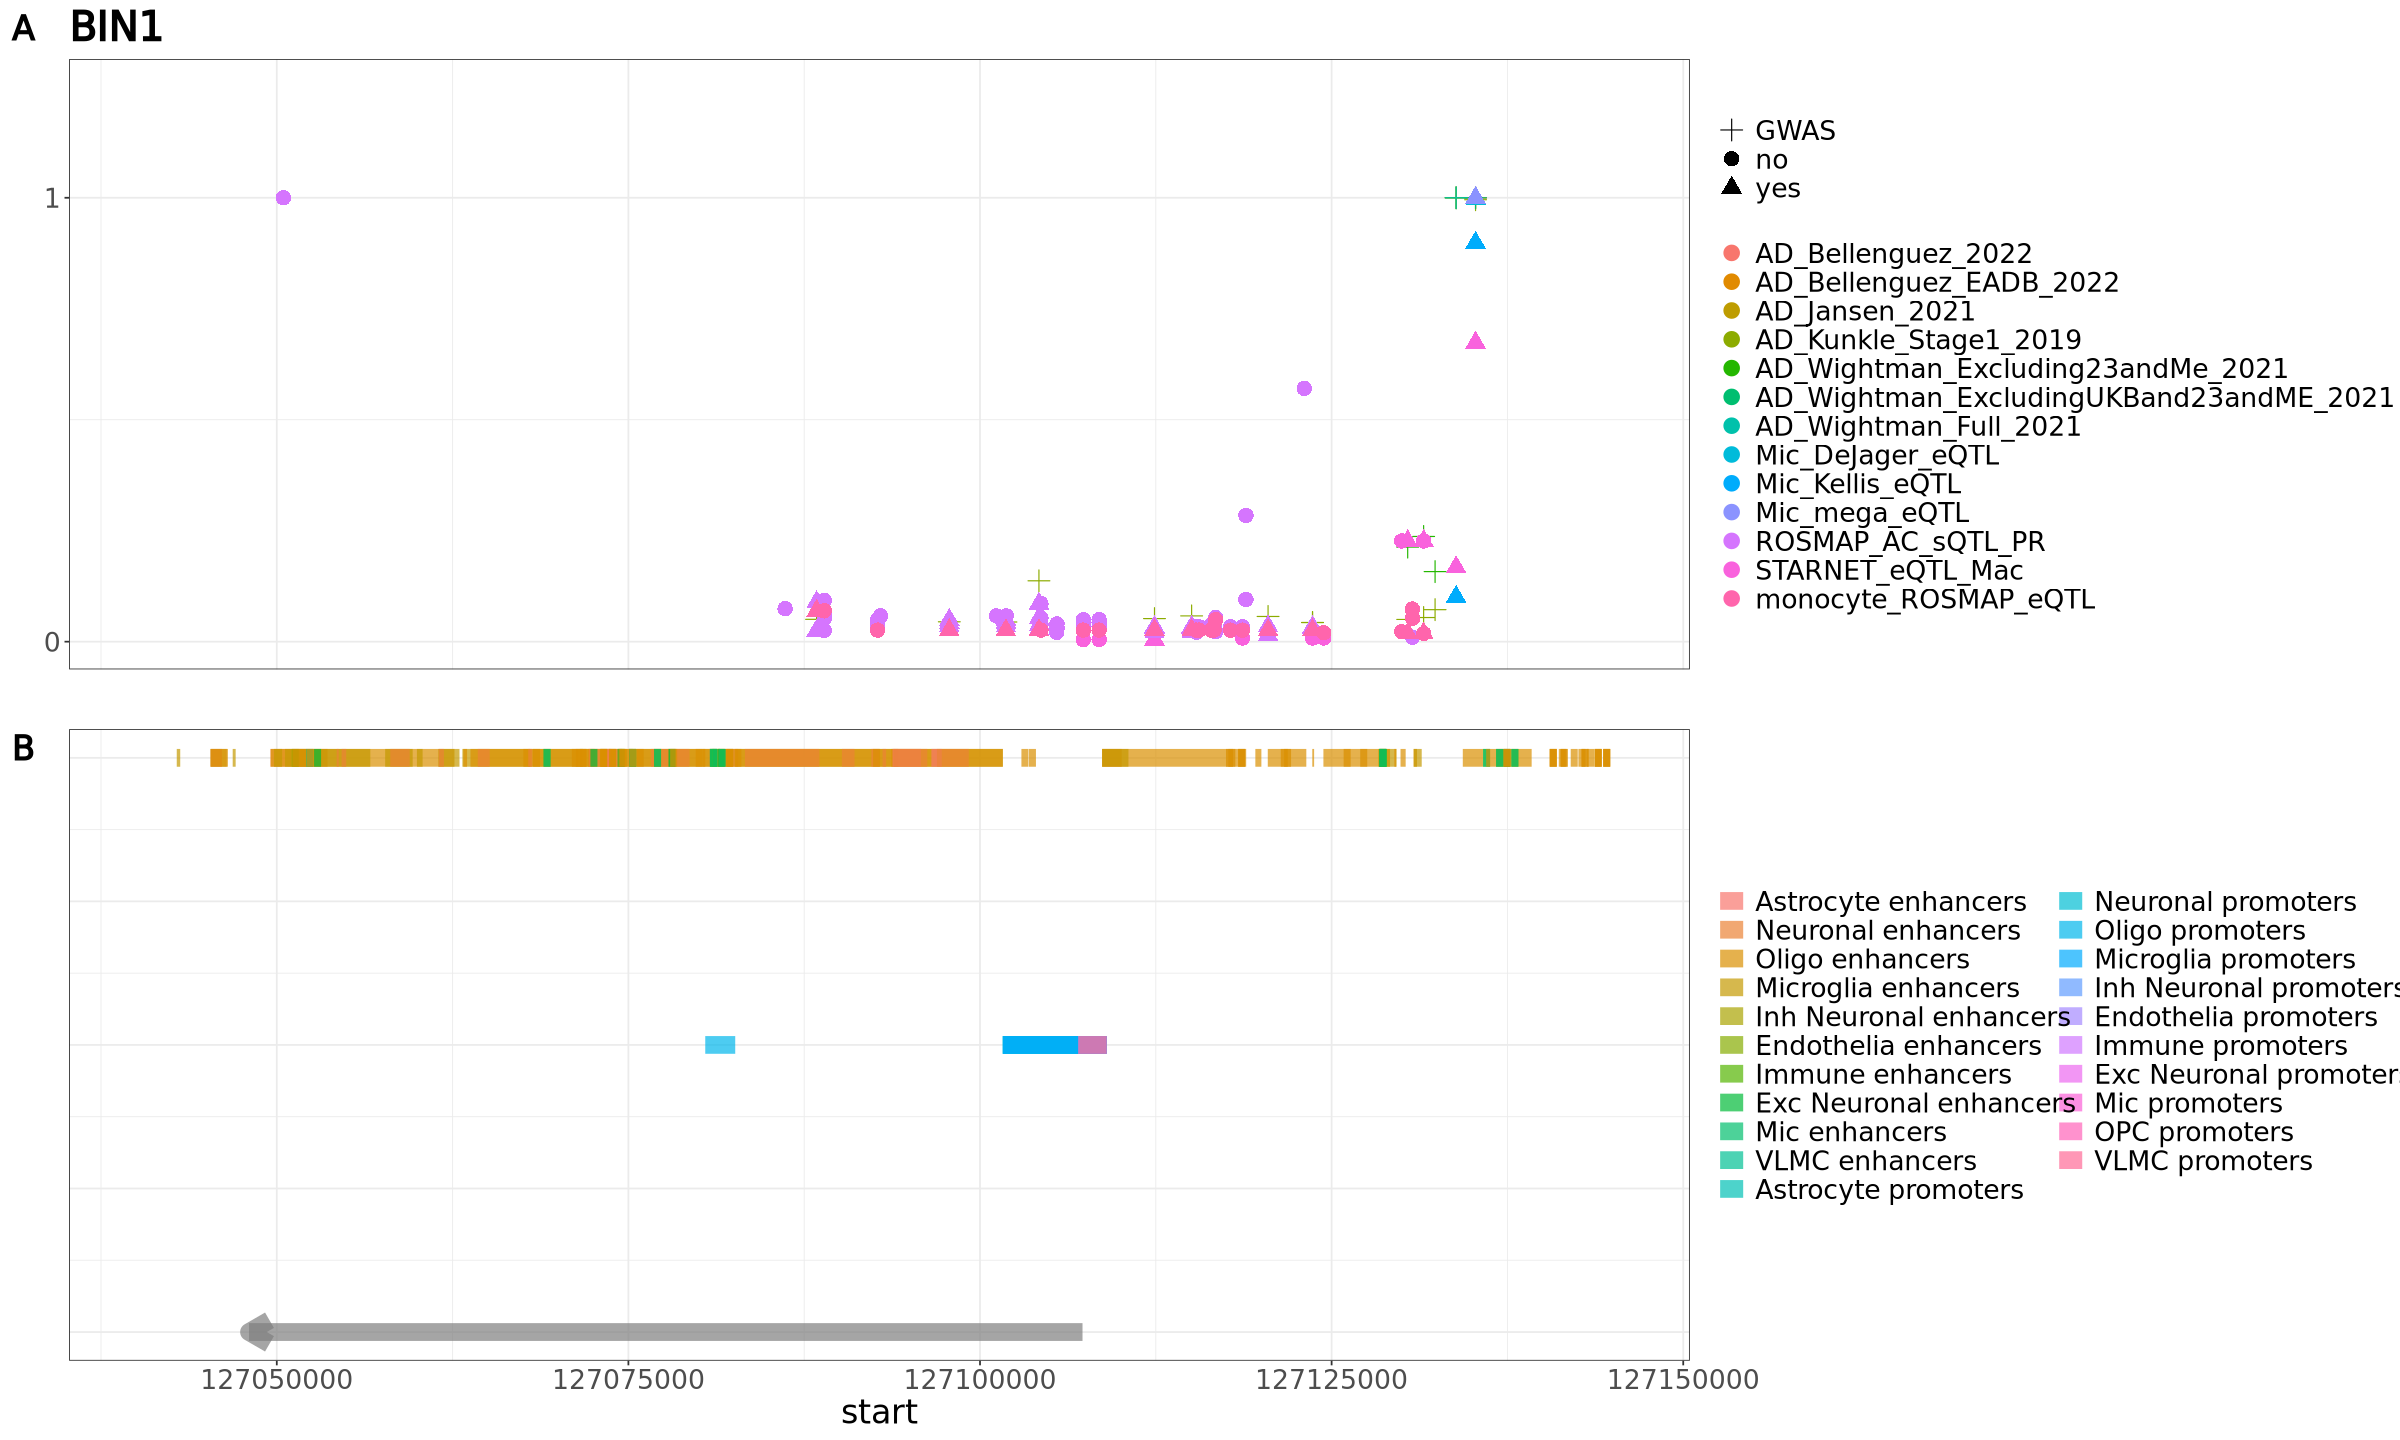

In [29]:
func_p

In [30]:
BIN1_com$context %>% unique()
BIN1_com%>%filter(is.na(context))
colnames(BIN1_com)
head(BIN1_com)
head(BIN1_result_olp_cs)

[1] "AD_Bellenguez_2022"                     
 [2] "AD_Bellenguez_EADB_2022"                
 [3] "AD_Jansen_2021"                         
 [4] "AD_Kunkle_Stage1_2019"                  
 [5] "AD_Wightman_Excluding23andMe_2021"      
 [6] "AD_Wightman_ExcludingUKBand23andME_2021"
 [7] "AD_Wightman_Full_2021"                  
 [8] "STARNET_eQTL_Mac"                       
 [9] "ROSMAP_AC_sQTL_PR"                      
[10] "monocyte_ROSMAP_eQTL"                   
[11] "Mic_Kellis_eQTL"                        
[12] "Mic_DeJager_eQTL"                       
[13] "Mic_mega_eQTL"

Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


Warning message in cbind(parts$left, chars$ellip_h, parts$right, deparse.level = 0L):
“number of rows of result is not a multiple of vector length (arg 2)”


study,variant_ID,region,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,z,cs_coverage_0.95_original,cs_coverage_0.7_original,⋯,end,start,a1,a2,context,gene_ID,conditional_effect,resource,lfsr,type
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>


[1] "study"                     "variant_ID"               
 [3] "region"                    "cs_coverage_0.95"         
 [5] "cs_coverage_0.7"           "cs_coverage_0.5"          
 [7] "PIP"                       "z"                        
 [9] "cs_coverage_0.95_original" "cs_coverage_0.7_original" 
[11] "cs_coverage_0.5_original"  "event_ID"                 
[13] "variant_id_flip"           "chr"                      
[15] "pos"                       "cs_id_95"                 
[17] "cs_id_70"                  "cs_id_50"                 
[19] "overlapped_with_gwas"      "#chr"                     
[21] "end"                       "start"                    
[23] "a1"                        "a2"                       
[25] "context"                   "gene_ID"                  
[27] "conditional_effect"        "resource"                 
[29] "lfsr"                      "type"

study,variant_ID,region,cs_coverage_0.95,cs_coverage_0.7,cs_coverage_0.5,PIP,z,cs_coverage_0.95_original,cs_coverage_0.7_original,⋯,end,start,a1,a2,context,gene_ID,conditional_effect,resource,lfsr,type
<chr>,<chr>,<chr>,<int>,<int>,<int>,<dbl>,<dbl>,<int>,<int>,⋯,<int>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
AD_Bellenguez_2022,chr2:127133851:A:C,chr2_125689597_127728648,1,1,1,NA,NA,NA,NA,⋯,127133851,127133850,C,A,AD_Bellenguez_2022,NA,NA,NA,NA,NA
AD_Bellenguez_2022,chr2:127135234:C:T,chr2_125689597_127728648,1,1,1,1.0000000,20.07143,1,1,⋯,127135234,127135233,T,C,AD_Bellenguez_2022,NA,NA,NA,NA,NA
AD_Bellenguez_EADB_2022,chr2:127133851:A:C,chr2_125689597_127728648,1,1,1,NA,NA,NA,NA,⋯,127133851,127133850,C,A,AD_Bellenguez_EADB_2022,NA,NA,NA,NA,NA
AD_Bellenguez_EADB_2022,chr2:127135234:C:T,chr2_125689597_127728648,1,1,1,0.9996894,13.21241,1,1,⋯,127135234,127135233,T,C,AD_Bellenguez_EADB_2022,NA,NA,NA,NA,NA
AD_Jansen_2021,chr2:127133851:A:C,chr2_125689597_127728648,1,1,1,1.0000000,14.00534,1,1,⋯,127133851,127133850,C,A,AD_Jansen_2021,NA,NA,NA,NA,NA
AD_Jansen_2021,chr2:127135234:C:T,chr2_125689597_127728648,1,1,1,NA,NA,NA,NA,⋯,127135234,127135233,T,C,AD_Jansen_2021,NA,NA,NA,NA,NA


#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,⋯,conditional_effect,context,resource,lfsr,z,type,cs_id_95,cs_id_70,cs_id_50,overlapped_with_gwas
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
2,127107344,127107345,G,C,chr2:127107345:C:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127107345,127107346,C,G,chr2:127107346:G:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127108470,127108471,T,C,chr2:127108471:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127112405,127112406,T,C,chr2:127112406:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,yes
2,127118665,127118666,T,C,chr2:127118666:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.391241771694759,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127123642,127123643,A,G,chr2:127123643:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.391241771694759,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no


In [31]:
head(BIN1_result_olp_cs)

#chr,start,end,a1,a2,variant_ID,gene_ID,event_ID,cs_coverage_0.95,cs_coverage_0.7,⋯,conditional_effect,context,resource,lfsr,z,type,cs_id_95,cs_id_70,cs_id_50,overlapped_with_gwas
<int>,<dbl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,⋯,<chr>,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>
2,127107344,127107345,G,C,chr2:127107345:C:G,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127107345,127107346,C,G,chr2:127107346:G:C,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127108470,127108471,T,C,chr2:127108471:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127112405,127112406,T,C,chr2:127112406:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.386533787604943,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,yes
2,127118665,127118666,T,C,chr2:127118666:C:T,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.391241771694759,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
2,127123642,127123643,A,G,chr2:127123643:G:A,ENSG00000136717,STARNET_eQTL_Mac_ENSG00000136717,3,0,⋯,-0.391241771694759,STARNET_eQTL_Mac,single_context,NA,NA,eQTL,eQTL_STARNET_eQTL_Mac_3,NA,NA,no
